## Notebook summary

| Item | Details |
| --- | --- |
| Purpose | DenseNet-121 Two-Arm Preprocessing Confirmation |
| Model / workflow | DenseNet-121/201 |
| Input | not reported |
| Loss | Cross-Entropy (CE) |
| Training / pipeline | Native-CAM experiment |
| Result | "loss_type": "ce",; current_pad_then_clahe2 / epoch 01 / warmup / QWK=0.3098 / F1=0.2691 / G1R=0.2484 / AP=0.2889 / selection=0.2945; current_pad_then_clahe2 / epoch 02 / warmup / QWK=0.3781 / F1=0.2432 / G1R=0.1373 / AP=0.3325 / selection=0.3308 |


# DenseNet-121 Two-Arm Preprocessing Confirmation

This focused validation-only experiment repeats the two relevant preprocessing arms from scratch:

- `current_pad_then_clahe2`: deployed order, square padding before LAB CLAHE `2.0`.
- `clahe1_25_then_pad`: candidate order, LAB CLAHE `1.25` before square padding.

Both arms use the same DenseNet-121 native-CAM architecture, CE loss, split, seed, sampler, augmentation, and 5/15/10 epoch schedule. The test split is never loaded. This run removes the interrupted-optimizer confound from the original six-arm ablation.


## Execution

Run every cell from top to bottom in one A100 or T4 Colab runtime. The notebook trains exactly two complete 5/15/10-stage arms and saves checkpoints in one unique timestamped confirmation directory. Resume is automatic after interruption. Do not skip the preprocessing preview, CAM audit, comparison, report, or runtime-release cells.


In [1]:
import csv
import gc
import hashlib
import json
import os
import random
import subprocess
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import tqdm
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab; Drive mount skipped.")

try:
    import timm
except ImportError:
    subprocess.run(["pip", "install", "-q", "timm"], check=True)
    import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

dataset_zip = Path("/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip")
if dataset_zip.exists():
    subprocess.run(
        ["unzip", "-q", "-o", str(dataset_zip), "-d", "/content/Datasets"],
        check=True,
    )

DATASET_ROOT = Path("/content/Datasets/kaggle_knee_osteoarthritis")
RUN_PARENT = Path("/content/drive/MyDrive/Models/densenet121_checkpoints")
requested_resume_dir = os.environ.get("PREPROCESSING_CONFIRMATION_RESUME_DIR")
incomplete_runs = sorted(
    path for path in RUN_PARENT.glob("*_preprocessing_confirmation")
    if path.is_dir() and not (path / "run_manifest.json").exists()
)
if requested_resume_dir:
    RUN_DIR = Path(requested_resume_dir)
elif incomplete_runs:
    RUN_DIR = incomplete_runs[-1]
else:
    RUN_TIMESTAMP = datetime.now(timezone.utc).strftime("%Y-%m-%d_%H-%M-%S_%f_UTC")
    RUN_DIR = RUN_PARENT / f"{RUN_TIMESTAMP}_preprocessing_confirmation"
RUN_TIMESTAMP = RUN_DIR.name.split("_preprocessing_confirmation")[0]
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run directory: {RUN_DIR}")


Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Run directory: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-26_06-44-07_628595_UTC_preprocessing_confirmation


## Fixed Data and Controlled Preprocessing

Enhancement is performed on the detected knee ROI. Pre-padding arms avoid
including synthetic black padding in histogram estimation. Validation is
deterministic and always uses the same preprocessing assigned to its arm.


In [2]:
class SquarePad:
    def __call__(self, image):
        height, width = image.shape[:2]
        side = max(height, width)
        top = (side - height) // 2
        bottom = side - height - top
        left = (side - width) // 2
        right = side - width - left
        return cv2.copyMakeBorder(
            image, top, bottom, left, right,
            cv2.BORDER_CONSTANT, value=[0, 0, 0],
        )


class IdentityEnhancement:
    def __call__(self, image):
        return image


class CLAHE:
    def __init__(self, clip_limit):
        self.clip_limit = float(clip_limit)

    def __call__(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lightness, channel_a, channel_b = cv2.split(lab)
        lightness = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=(8, 8),
        ).apply(lightness)
        return cv2.cvtColor(
            cv2.merge((lightness, channel_a, channel_b)),
            cv2.COLOR_LAB2RGB,
        )


class PercentileWindow:
    def __init__(self, low=1.0, high=99.0):
        self.low = float(low)
        self.high = float(high)

    def __call__(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        low, high = np.percentile(gray, [self.low, self.high])
        if high <= low + 1.0:
            return image
        scaled = (image.astype(np.float32) - low) * (255.0 / (high - low))
        return np.clip(scaled, 0, 255).astype(np.uint8)


class RandomGammaCorrection:
    def __init__(self, gamma_range=(0.85, 1.15)):
        self.gamma_range = tuple(gamma_range)

    def __call__(self, image):
        gamma = random.uniform(*self.gamma_range)
        return TF.adjust_gamma(image, gamma=gamma, gain=1.0)


class RandomBlurOrSharpness:
    def __call__(self, image):
        draw = random.random()
        if draw < 0.15:
            sigma = random.uniform(0.1, 0.8)
            return TF.gaussian_blur(image, kernel_size=[3, 3], sigma=[sigma, sigma])
        if draw < 0.30:
            factor = random.uniform(0.70, 1.40)
            return TF.adjust_sharpness(image, factor)
        return image


class RandomGaussianNoise:
    def __init__(self, probability=0.20, std_range=(0.005, 0.020)):
        self.probability = float(probability)
        self.std_range = tuple(std_range)

    def __call__(self, tensor):
        if random.random() >= self.probability:
            return tensor
        std = random.uniform(*self.std_range)
        return (tensor + torch.randn_like(tensor) * std).clamp(0, 1)


DETERMINISTIC_SPECS = [
    {
        "name": "current_pad_then_clahe2",
        "enhancement": "clahe",
        "clip_limit": 2.0,
        "enhance_before_padding": False,
        "acquisition_augmentation": False,
        "loss_type": "ce",
        "ordinal_weight": 0.0,
    },
    {
        "name": "clahe1_25_then_pad",
        "enhancement": "clahe",
        "clip_limit": 1.25,
        "enhance_before_padding": True,
        "acquisition_augmentation": False,
        "loss_type": "ce",
        "ordinal_weight": 0.0,
    },
]


def build_enhancement(spec):
    if spec["enhancement"] == "none":
        return IdentityEnhancement()
    if spec["enhancement"] == "clahe":
        return CLAHE(spec["clip_limit"])
    if spec["enhancement"] == "percentile_1_99":
        return PercentileWindow(1.0, 99.0)
    raise ValueError(f"Unknown enhancement: {spec['enhancement']}")


def deterministic_operations(spec):
    enhancement = build_enhancement(spec)
    if spec["enhance_before_padding"]:
        return [enhancement, SquarePad()]
    return [SquarePad(), enhancement]


def build_train_transform(spec):
    operations = deterministic_operations(spec)
    operations.extend([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=0.50),
        transforms.RandomRotation(5),
        transforms.ColorJitter(brightness=0.08, contrast=0.08),
    ])
    if spec["acquisition_augmentation"]:
        operations.extend([
            transforms.RandomApply([RandomGammaCorrection()], p=0.30),
            RandomBlurOrSharpness(),
        ])
    operations.extend([
        transforms.Resize((384, 384)),
        transforms.ToTensor(),
    ])
    if spec["acquisition_augmentation"]:
        operations.append(RandomGaussianNoise())
    operations.extend([
        transforms.RandomErasing(
            p=0.10,
            scale=(0.02, 0.05),
            ratio=(0.5, 2.0),
            value=0,
        ),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])
    return transforms.Compose(operations)


def build_evaluation_transform(spec):
    return transforms.Compose([
        *deterministic_operations(spec),
        transforms.ToPILImage(),
        transforms.Resize((384, 384)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])


def file_digest(path):
    digest = hashlib.sha256()
    with open(path, "rb") as image_file:
        for chunk in iter(lambda: image_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def index_split(split, excluded_hashes=None):
    split_dir = DATASET_ROOT / split
    if not split_dir.is_dir():
        raise FileNotFoundError(f"Dataset split is missing: {split_dir}")
    excluded_hashes = excluded_hashes or set()
    retained_hashes, paths, labels = set(), [], []
    for grade in range(5):
        grade_dir = split_dir / str(grade)
        for path in sorted(grade_dir.iterdir()):
            if path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
                continue
            digest = file_digest(path)
            if digest in excluded_hashes or digest in retained_hashes:
                continue
            retained_hashes.add(digest)
            paths.append(str(path))
            labels.append(grade)
    print(f"{split}: {len(paths)} unique images")
    return paths, labels, retained_hashes


class KneeDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = cv2.imread(path)
        if image is None:
            raise IOError(f"Could not read image: {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return self.transform(image), self.labels[index], path


train: 5778 unique images
val: 826 unique images
Train class counts: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Deterministic preprocessing arms:
{
  "name": "current_pad_then_clahe2",
  "enhancement": "clahe",
  "clip_limit": 2.0,
  "enhance_before_padding": false,
  "acquisition_augmentation": false,
  "loss_type": "ce",
  "ordinal_weight": 0.0
}
{
  "name": "clahe1_25_then_pad",
  "enhancement": "clahe",
  "clip_limit": 1.25,
  "enhance_before_padding": true,
  "acquisition_augmentation": false,
  "loss_type": "ce",
  "ordinal_weight": 0.0
}


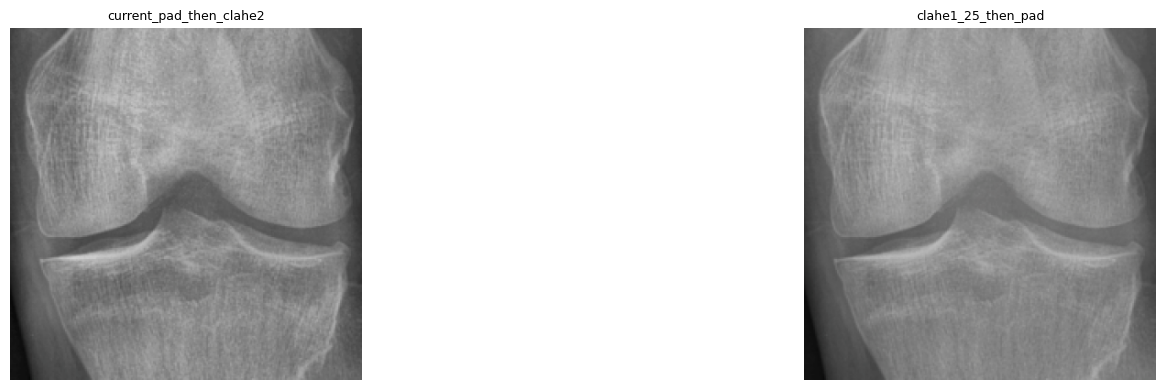

In [3]:
train_paths, train_labels, train_hashes = index_split("train")
validation_paths, validation_labels, validation_hashes = index_split(
    "val", train_hashes
)
print("Train class counts:", dict(sorted(Counter(train_labels).items())))
print("Deterministic preprocessing arms:")
for spec in DETERMINISTIC_SPECS:
    print(json.dumps(spec, indent=2))

preview_source = cv2.cvtColor(
    cv2.imread(train_paths[len(train_paths) // 2]),
    cv2.COLOR_BGR2RGB,
)
figure, axes = plt.subplots(1, len(DETERMINISTIC_SPECS), figsize=(20, 4))
for axis, spec in zip(axes, DETERMINISTIC_SPECS):
    preview = preview_source.copy()
    for operation in deterministic_operations(spec):
        preview = operation(preview)
    preview = cv2.resize(preview, (384, 384), interpolation=cv2.INTER_AREA)
    axis.imshow(preview)
    axis.set_title(spec["name"], fontsize=9)
    axis.axis("off")
figure.tight_layout()
figure.savefig(RUN_DIR / "preprocessing_preview.png", dpi=180)
plt.show()


## Fixed Five-Class Native-CAM DenseNet-121

The architecture is unchanged. A bias-free 1x1 class convolution followed by
global average pooling produces five KL logits and the corresponding native
class maps.


In [4]:
class DenseNet121NativeCAM(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            "densenet121",
            pretrained=pretrained,
            features_only=True,
            out_indices=(4,),
        )
        channels = self.backbone.feature_info.channels()[0]
        self.class_conv = nn.Conv2d(channels, 5, kernel_size=1)

    def class_maps(self, images):
        return self.class_conv(self.backbone(images)[0])

    def forward(self, images):
        return self.class_maps(images).mean(dim=(2, 3))

    def native_cam(self, images, class_indices=None):
        with torch.no_grad():
            maps = self.class_maps(images)
            logits = maps.mean(dim=(2, 3))
            if class_indices is None:
                class_indices = logits.argmax(dim=1)
            class_indices = torch.as_tensor(
                class_indices, device=images.device, dtype=torch.long
            ).reshape(-1)
            selected = maps[
                torch.arange(images.size(0), device=images.device),
                class_indices,
            ]
            selected = F.relu(selected).unsqueeze(1)
            selected = F.interpolate(
                selected,
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False,
            ).squeeze(1)
            maxima = selected.flatten(1).amax(1).clamp_min(1e-8)
            selected = selected / maxima[:, None, None]
        return selected, logits

    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_final_stages(self):
        for parameter in self.parameters():
            parameter.requires_grad = False
        matched = 0
        for name, parameter in self.backbone.named_parameters():
            if any(token in name for token in ("denseblock3", "denseblock4")):
                parameter.requires_grad = True
                matched += parameter.numel()
        if matched == 0:
            raise RuntimeError("Could not resolve the final backbone stages.")
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_all(self):
        for parameter in self.parameters():
            parameter.requires_grad = True


## Shared CE Training and Frozen CAM Audit

Each of the two arms resets seed 42 and trains for 5/15/10 epochs. Epoch checkpoints are
selected using `0.55*QWK + 0.30*macro-F1 + 0.15*macro-AP`. After training,
up to 50 validation cases per grade receive predicted- and true-class CAMs,
production gate metrics, joint occlusion, flip consistency, and an input
sharpness measurement.


In [5]:
def adjustable_ordinal_pd2(logits, labels):
    """Chen et al. PD-2 ordinal loss, normalized for stable optimization."""
    probabilities = F.softmax(logits.float(), dim=1)
    grades = torch.arange(logits.size(1), device=logits.device)
    distance = (grades[None, :] - labels[:, None]).abs().float()
    expected_pd2 = (probabilities * (2.0 * distance)).sum(dim=1)
    # Divide by the maximum PD-2 distance before squaring.
    return (expected_pd2 / (2.0 * (logits.size(1) - 1))).square().mean()


def calculate_loss(logits, labels, spec):
    if spec["loss_type"] == "ce":
        return F.cross_entropy(logits, labels)
    ordinal = adjustable_ordinal_pd2(logits, labels)
    if spec["loss_type"] == "ordinal_pd2":
        return ordinal
    if spec["loss_type"] == "ce_plus_ordinal_pd2":
        return F.cross_entropy(logits, labels) + spec["ordinal_weight"] * ordinal
    raise ValueError(f"Unsupported loss: {spec['loss_type']}")


def calculate_metrics(labels, predictions, probabilities):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, labels=[0, 1, 2, 3, 4],
        average="macro", zero_division=0
    )
    grade1_precision, grade1_recall, _, _ = precision_recall_fscore_support(
        labels == 1, predictions == 1, average="binary", zero_division=0
    )
    one_hot = np.eye(5)[labels]
    metrics = {
        "accuracy": float(accuracy_score(labels, predictions)),
        "qwk": float(cohen_kappa_score(labels, predictions, weights="quadratic")),
        "mae": float(np.mean(np.abs(labels - predictions))),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "grade1_precision": float(grade1_precision),
        "grade1_recall": float(grade1_recall),
        "macro_ap": float(average_precision_score(one_hot, probabilities, average="macro")),
        "macro_auc": float(roc_auc_score(one_hot, probabilities, average="macro")),
    }
    metrics["selection_score"] = float(
        0.55 * metrics["qwk"]
        + 0.30 * metrics["macro_f1"]
        + 0.15 * metrics["macro_ap"]
    )
    return metrics


def train_one_epoch(model, loader, optimizer, scaler, spec, description):
    model.train()
    running_loss = 0.0
    for images, labels, _ in tqdm.tqdm(loader, desc=description, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
            logits = model(images)
            loss = calculate_loss(logits, labels, spec)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, spec, description):
    model.eval()
    labels_all, predictions_all, probabilities_all, paths_all = [], [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for images, labels, paths in tqdm.tqdm(loader, desc=description, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probabilities = F.softmax(logits.float(), dim=1)
            total_loss += calculate_loss(logits, labels, spec).item() * labels.size(0)
            labels_all.extend(labels.cpu().numpy())
            predictions_all.extend(probabilities.argmax(1).cpu().numpy())
            probabilities_all.extend(probabilities.cpu().numpy())
            paths_all.extend(paths)
    metrics = calculate_metrics(labels_all, predictions_all, probabilities_all)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics, np.asarray(labels_all), np.asarray(predictions_all), np.asarray(probabilities_all), paths_all



def load_checkpoint(path):
    """Load experiment checkpoints across PyTorch versions."""
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)



def normalized_edge_sharpness(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    image = (tensor.cpu() * std + mean).clamp(0, 1)
    gray = 0.299 * image[0] + 0.587 * image[1] + 0.114 * image[2]
    low = torch.quantile(gray, 0.01)
    high = torch.quantile(gray, 0.99)
    gray = ((gray - low) / (high - low).clamp_min(1e-6)).clamp(0, 1)
    gradient_x = gray[:, 1:] - gray[:, :-1]
    gradient_y = gray[1:, :] - gray[:-1, :]
    return float(
        10000.0
        * (gradient_x.square().mean() + gradient_y.square().mean())
    )


def cam_geometry(cam):
    height, width = cam.shape
    joint = np.zeros((height, width), dtype=bool)
    joint[
        int(0.28 * height):int(0.72 * height),
        int(0.06 * width):int(0.94 * width),
    ] = True
    border = np.ones((height, width), dtype=bool)
    border[
        int(0.08 * height):int(0.92 * height),
        int(0.08 * width):int(0.92 * width),
    ] = False
    lower_tibia = np.zeros((height, width), dtype=bool)
    lower_tibia[
        int(0.72 * height):int(0.96 * height),
        int(0.06 * width):int(0.94 * width),
    ] = True
    total = float(cam.sum()) + 1e-8
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    joint_energy = float(cam[joint].sum()) / total
    border_energy = float(cam[border].sum()) / total
    lower_tibia_energy = float(cam[lower_tibia].sum()) / total
    peak_inside_joint = bool(joint[peak] and total > 1e-7)
    anatomy_score = (
        joint_energy
        * (1.0 - border_energy)
        * (1.0 - lower_tibia_energy)
    )
    gate_pass = (
        joint_energy >= 0.55
        and border_energy <= 0.25
        and lower_tibia_energy <= 0.25
        and peak_inside_joint
    )
    return {
        "joint_energy": joint_energy,
        "border_energy": border_energy,
        "lower_tibia_energy": lower_tibia_energy,
        "peak_inside_joint": int(peak_inside_joint),
        "anatomy_score": anatomy_score,
        "gate_pass": int(gate_pass),
    }


def audit_native_cam(model, dataset, output_dir, seed=42):
    rng = np.random.default_rng(seed)
    audit_indices = []
    labels_array = np.asarray(dataset.labels)
    for grade in range(5):
        grade_indices = np.flatnonzero(labels_array == grade)
        rng.shuffle(grade_indices)
        audit_indices.extend(
            grade_indices[:min(50, len(grade_indices))].tolist()
        )

    rows, cached = [], {}
    model.eval()
    for index in tqdm.tqdm(audit_indices, desc="NATIVE CAM AUDIT", leave=False):
        tensor, true_grade, path = dataset[index]
        input_sharpness = normalized_edge_sharpness(tensor)
        batch = tensor[None].to(device)
        with torch.no_grad():
            logits = model(batch)
            predicted_grade = int(logits.argmax(1).item())
        predicted_cam, _ = model.native_cam(batch, [predicted_grade])
        true_cam, _ = model.native_cam(batch, [int(true_grade)])

        # Faithfulness: mask the central joint band with normalized mean pixels and
        # measure the selected-grade probability decrease.
        height, width = batch.shape[-2:]
        y0, y1 = int(0.28 * height), int(0.72 * height)
        x0, x1 = int(0.06 * width), int(0.94 * width)
        occluded = batch.clone()
        occluded[:, :, y0:y1, x0:x1] = 0.0
        with torch.no_grad():
            probabilities = F.softmax(logits.float(), dim=1)
            occluded_probabilities = F.softmax(model(occluded).float(), dim=1)
        occlusion_drop = float(
            probabilities[0, predicted_grade]
            - occluded_probabilities[0, predicted_grade]
        )

        # Natural-orientation robustness: flip the input, flip its CAM back, then
        # compare predictions and spatial evidence in the original coordinates.
        flipped_batch = torch.flip(batch, dims=[3])
        with torch.no_grad():
            flipped_logits = model(flipped_batch)
            flipped_probabilities = F.softmax(flipped_logits.float(), dim=1)
        flipped_cam, _ = model.native_cam(flipped_batch, [predicted_grade])
        flipped_cam = torch.flip(flipped_cam, dims=[2])[0].cpu().numpy()
        probability_p = probabilities[0].clamp_min(1e-8)
        probability_q = flipped_probabilities[0].clamp_min(1e-8)
        probability_m = 0.5 * (probability_p + probability_q)
        flip_js_divergence = float(
            0.5 * torch.sum(probability_p * torch.log(probability_p / probability_m))
            + 0.5 * torch.sum(probability_q * torch.log(probability_q / probability_m))
        )

        predicted_cam = predicted_cam[0].cpu().numpy()
        true_cam = true_cam[0].cpu().numpy()
        if predicted_cam.std() > 1e-8 and flipped_cam.std() > 1e-8:
            flip_cam_correlation = float(
                np.corrcoef(predicted_cam.ravel(), flipped_cam.ravel())[0, 1]
            )
        else:
            flip_cam_correlation = 0.0
        row = {
            "dataset_index": index,
            "path": path,
            "true_grade": int(true_grade),
            "predicted_grade": predicted_grade,
            "input_sharpness": input_sharpness,
            "joint_occlusion_probability_drop": occlusion_drop,
            "flip_js_divergence": flip_js_divergence,
            "flip_cam_correlation": flip_cam_correlation,
            "flip_prediction_consistent": int(flipped_probabilities.argmax(1).item() == predicted_grade),
            **{
                f"predicted_{key}": value
                for key, value in cam_geometry(predicted_cam).items()
            },
            **{
                f"true_{key}": value
                for key, value in cam_geometry(true_cam).items()
            },
        }
        rows.append(row)
        cached[index] = (tensor, predicted_cam, true_cam)

    with open(output_dir / "native_cam_audit.csv", "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)

    summary = {
        "audited_cases": len(rows),
        "joint_energy": float(np.mean([
            row["predicted_joint_energy"] for row in rows
        ])),
        "border_energy": float(np.mean([
            row["predicted_border_energy"] for row in rows
        ])),
        "lower_tibia_energy": float(np.mean([
            row["predicted_lower_tibia_energy"] for row in rows
        ])),
        "peak_inside_joint_rate": float(np.mean([
            row["predicted_peak_inside_joint"] for row in rows
        ])),
        "gate_pass_rate": float(np.mean([
            row["predicted_gate_pass"] for row in rows
        ])),
        "anatomy_score": float(np.mean([
            row["predicted_anatomy_score"] for row in rows
        ])),
        "input_sharpness": float(np.mean([
            row["input_sharpness"] for row in rows
        ])),
        "sharpness_anatomy_correlation": float(np.corrcoef(
            [row["input_sharpness"] for row in rows],
            [row["predicted_anatomy_score"] for row in rows],
        )[0, 1]),
        "joint_occlusion_probability_drop": float(np.mean([
            row["joint_occlusion_probability_drop"] for row in rows
        ])),
        "flip_js_divergence": float(np.mean([
            row["flip_js_divergence"] for row in rows
        ])),
        "flip_cam_correlation": float(np.mean([
            row["flip_cam_correlation"] for row in rows
        ])),
        "flip_prediction_consistency": float(np.mean([
            row["flip_prediction_consistent"] for row in rows
        ])),
    }
    with open(output_dir / "native_cam_summary.json", "w") as handle:
        json.dump(summary, handle, indent=2)

    worst = sorted(
        rows,
        key=lambda row: (
            1 - row["predicted_peak_inside_joint"]
            + row["predicted_border_energy"]
            + row["predicted_lower_tibia_energy"]
        ),
        reverse=True,
    )[:8]
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    figure, axes = plt.subplots(len(worst), 3, figsize=(12, 4 * len(worst)))
    for row_index, row in enumerate(worst):
        tensor, predicted_cam, true_cam = cached[row["dataset_index"]]
        image = (
            (tensor.cpu() * std + mean)
            .clamp(0, 1)
            .permute(1, 2, 0)
            .numpy()
        )
        axes[row_index, 0].imshow(image)
        axes[row_index, 0].set_title(
            f"True G{row['true_grade']} | predicted G{row['predicted_grade']}"
        )
        axes[row_index, 1].imshow(image)
        axes[row_index, 1].imshow(predicted_cam, cmap="jet", alpha=0.40)
        axes[row_index, 1].set_title("Predicted-class native CAM")
        axes[row_index, 2].imshow(image)
        axes[row_index, 2].imshow(true_cam, cmap="jet", alpha=0.40)
        axes[row_index, 2].set_title("True-class native CAM")
        for axis in axes[row_index]:
            axis.axis("off")
    figure.tight_layout()
    figure.savefig(output_dir / "native_cam_worst_cases.png", dpi=180)
    plt.close(figure)
    return summary


In [6]:
def localization_score(cam):
    return float(
        0.40 * cam["gate_pass_rate"]
        + 0.30 * cam["joint_energy"]
        + 0.15 * (1.0 - cam["border_energy"])
        + 0.15 * (1.0 - cam["lower_tibia_energy"])
    )


def choose_candidate(results):
    best_classification = max(
        result["validation_metrics"]["selection_score"]
        for result in results.values()
    )
    eligible = {
        name: result
        for name, result in results.items()
        if result["validation_metrics"]["selection_score"]
        >= best_classification - 0.01
    }
    return max(
        eligible,
        key=lambda name: (
            eligible[name]["localization_score"],
            eligible[name]["validation_metrics"]["selection_score"],
        ),
    )


def train_arm(spec):
    seed_everything(42)
    arm_dir = RUN_DIR / spec["name"]
    arm_dir.mkdir(parents=True, exist_ok=True)
    train_dataset = KneeDataset(train_paths, train_labels, build_train_transform(spec))
    validation_dataset = KneeDataset(validation_paths, validation_labels, build_evaluation_transform(spec))
    class_counts = Counter(train_dataset.labels)
    sample_weights = [1.0 / class_counts[label] for label in train_dataset.labels]
    sampler = WeightedRandomSampler(
        sample_weights, len(sample_weights), replacement=True,
        generator=torch.Generator().manual_seed(42),
    )
    train_loader = DataLoader(
        train_dataset, batch_size=48, sampler=sampler, num_workers=4,
        pin_memory=device.type == "cuda", persistent_workers=True,
        generator=torch.Generator().manual_seed(42),
    )
    validation_loader = DataLoader(
        validation_dataset, batch_size=48, shuffle=False, num_workers=4,
        pin_memory=device.type == "cuda", persistent_workers=True,
    )

    model = DenseNet121NativeCAM(pretrained=True).to(device)
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    stage2_path = arm_dir / "stage2_best_model.pth"
    best_path = arm_dir / "best_model.pth"
    last_path = arm_dir / "last_model.pth"
    resume = load_checkpoint(last_path) if last_path.exists() else None
    resume_epoch = int(resume.get("epoch", 0)) if resume else 0
    history = list(resume.get("history", [])) if resume else []
    best_stage2_score = max(
        (item["selection_score"] for item in history if item["stage"] == "coarse"),
        default=-float("inf"),
    )
    best_final_score = max(
        (item["selection_score"] for item in history if item["stage"] == "finetune"),
        default=-float("inf"),
    )
    if resume_epoch:
        print(f"{spec['name']} | resuming after epoch {resume_epoch} from {last_path}")

    stage_specs = (("warmup", 5, 0), ("coarse", 15, 5), ("finetune", 10, 20))
    optimizer = None
    scheduler = None
    for stage_name, stage_epochs, stage_offset in stage_specs:
        stage_end = stage_offset + stage_epochs
        if resume_epoch >= stage_end:
            continue
        if stage_name == "warmup":
            model.freeze_backbone()
            optimizer = optim.AdamW(model.class_conv.parameters(), lr=3e-4, weight_decay=1e-4)
            scheduler = None
        elif stage_name == "coarse":
            model.unfreeze_final_stages()
            optimizer = optim.AdamW(
                [
                    {"params": [p for p in model.backbone.parameters() if p.requires_grad], "lr": 3e-5},
                    {"params": model.class_conv.parameters(), "lr": 3e-4},
                ], weight_decay=1e-4,
            )
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-7)
        else:
            model.unfreeze_all()
            optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-3)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-7)

        if resume and resume_epoch >= stage_offset:
            model.load_state_dict(resume["model_state_dict"])
            same_stage_checkpoint = resume.get("stage") == stage_name
            if same_stage_checkpoint and resume.get("optimizer_state_dict"):
                optimizer.load_state_dict(resume["optimizer_state_dict"])
            if same_stage_checkpoint and scheduler is not None and resume.get("scheduler_state_dict"):
                scheduler.load_state_dict(resume["scheduler_state_dict"])
            if same_stage_checkpoint and resume.get("scaler_state_dict"):
                scaler.load_state_dict(resume["scaler_state_dict"])
        elif stage_name == "finetune":
            if not stage2_path.exists():
                raise FileNotFoundError(f"No Stage 2 checkpoint for {spec['name']}")
            model.load_state_dict(load_checkpoint(stage2_path)["model_state_dict"])

        first_stage_epoch = max(0, resume_epoch - stage_offset) if resume else 0
        for stage_epoch in range(first_stage_epoch, stage_epochs):
            global_epoch = stage_offset + stage_epoch + 1
            train_loss = train_one_epoch(
                model, train_loader, optimizer, scaler, spec,
                f"{spec['name']} | {stage_name} {stage_epoch + 1}/{stage_epochs}",
            )
            validation_metrics, _, _, _, _ = evaluate(
                model, validation_loader, spec, f"{spec['name']} | VALIDATE"
            )
            history.append({"epoch": global_epoch, "stage": stage_name, "train_loss": train_loss, **validation_metrics})
            print(
                f"{spec['name']} | epoch {global_epoch:02d} | {stage_name} | "
                f"QWK={validation_metrics['qwk']:.4f} | F1={validation_metrics['macro_f1']:.4f} | "
                f"G1R={validation_metrics['grade1_recall']:.4f} | AP={validation_metrics['macro_ap']:.4f} | "
                f"selection={validation_metrics['selection_score']:.4f}"
            )
            if scheduler is not None:
                scheduler.step()
            payload = {
                "model_state_dict": model.state_dict(), "epoch": global_epoch,
                "stage": stage_name, "architecture": "final_linear_native_cam",
                "model_name": "densenet121", "loss_type": "ce",
                "validation_metrics": validation_metrics, "history": history,
                "run_timestamp": RUN_TIMESTAMP, "arm": spec,
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
                "scaler_state_dict": scaler.state_dict(),
                "fixed_training_config": {
                    "orientation": "natural_no_canonicalization", "input_resize": 384,
                    "input_crop": None, "batch_size": 48,
                    "sampler": "full_inverse_frequency", "stage_epochs": [5, 15, 10],
                    "learning_rates": [3e-4, 3e-5, 1e-5], "native_cam": True,
                },
            }
            if stage_name == "coarse" and validation_metrics["selection_score"] > best_stage2_score:
                best_stage2_score = validation_metrics["selection_score"]
                torch.save(payload, stage2_path)
            if stage_name == "finetune" and validation_metrics["selection_score"] > best_final_score:
                best_final_score = validation_metrics["selection_score"]
                torch.save(payload, best_path)
            torch.save(payload, last_path)
        resume = load_checkpoint(last_path) if last_path.exists() else resume
        resume_epoch = int(resume.get("epoch", global_epoch)) if resume else global_epoch

    if not best_path.exists():
        raise RuntimeError(f"{spec['name']} produced no final checkpoint")
    best_checkpoint = load_checkpoint(best_path)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    cam_summary = audit_native_cam(model, validation_dataset, arm_dir)
    result = {
        "arm": spec, "checkpoint": str(best_path),
        "best_epoch": int(best_checkpoint["epoch"]),
        "validation_metrics": best_checkpoint["validation_metrics"],
        "native_cam_summary": cam_summary,
        "localization_score": localization_score(cam_summary),
    }
    with open(arm_dir / "arm_manifest.json", "w") as handle:
        json.dump(result, handle, indent=2)
    del model, optimizer, scaler, train_loader, validation_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


arm_results = {}
for arm_spec in DETERMINISTIC_SPECS:
    manifest_path = RUN_DIR / arm_spec["name"] / "arm_manifest.json"
    if manifest_path.exists():
        print(f"\n===== SKIPPING COMPLETED {arm_spec['name']} =====")
        with open(manifest_path) as handle:
            arm_results[arm_spec["name"]] = json.load(handle)
    else:
        print(f"\n===== TRAINING {arm_spec['name']} =====")
        arm_results[arm_spec["name"]] = train_arm(arm_spec)

selected_arm_name = choose_candidate(arm_results)
deterministic_winner = selected_arm_name
selected_result = arm_results[selected_arm_name]
selected_path = Path(selected_result["checkpoint"])
print(f"Confirmation winner: {selected_arm_name}")
print(f"Validation-selected preprocessing: {selected_arm_name}")
print(f"Selected checkpoint: {selected_path}")



===== TRAINING current_pad_then_clahe2 =====


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 32.3MB            

model.safetensors: downloading bytes:           |  0.00B            

current_pad_then_clahe2 | warmup 1/5:   0%|          | 0/121 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

clahe1_25_then_pad | epoch 27 | finetune | QWK=0.8102 | F1=0.6772 | G1R=0.4771 | AP=0.7345 | selection=0.7589


clahe1_25_then_pad | epoch 28 | finetune | QWK=0.8092 | F1=0.6842 | G1R=0.4837 | AP=0.7336 | selection=0.7603


clahe1_25_then_pad | epoch 29 | finetune | QWK=0.8108 | F1=0.6815 | G1R=0.5033 | AP=0.7346 | selection=0.7606


clahe1_25_then_pad | epoch 30 | finetune | QWK=0.8142 | F1=0.6846 | G1R=0.4837 | AP=0.7366 | selection=0.7637


Confirmation winner: clahe1_25_then_pad
Validation-selected preprocessing: clahe1_25_then_pad
Selected checkpoint: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-26_06-44-07_628595_UTC_preprocessing_confirmation/clahe1_25_then_pad/best_model.pth


## Validation Comparison and Production Candidate

The test directory is deliberately not loaded. An arm is eligible only when
its classification selection score is within `0.01` of the best arm; among
eligible arms, the higher localization score wins. This prevents a visually
attractive CAM from hiding a material KL-grading regression.


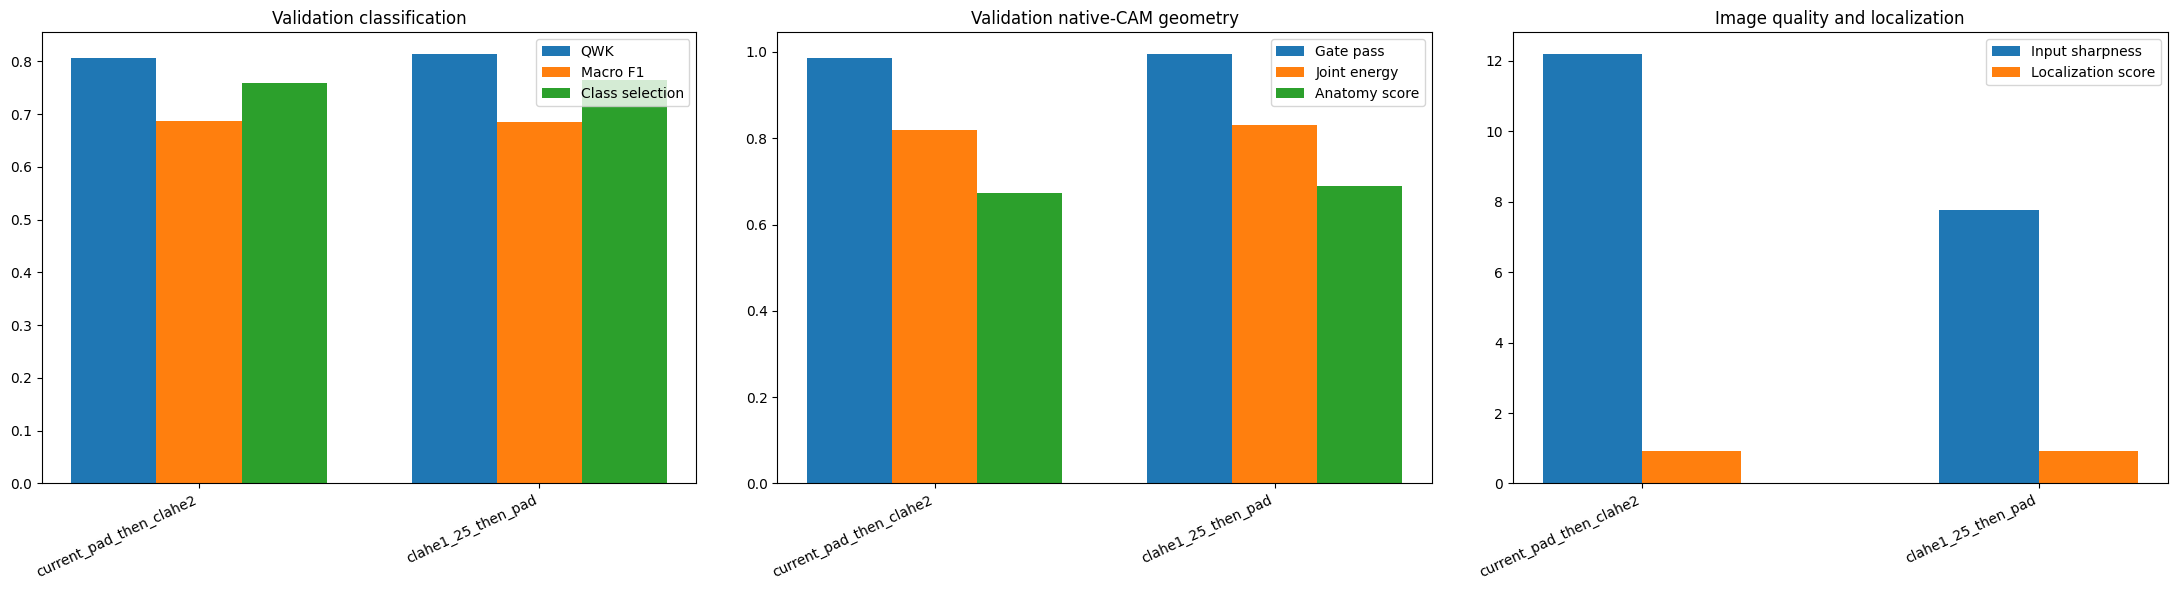

{
  "arm": "current_pad_then_clahe2",
  "enhancement": "clahe",
  "clip_limit": 2.0,
  "enhance_before_padding": false,
  "acquisition_augmentation": false,
  "best_epoch": 25,
  "qwk": 0.8064970885688018,
  "macro_f1": 0.6877679225902406,
  "macro_recall": 0.6959419775477814,
  "grade1_recall": 0.43137254901960786,
  "macro_ap": 0.7316185711255265,
  "macro_auc": 0.886516702317175,
  "classification_selection": 0.7596465611587422,
  "cam_gate_pass_rate": 0.986784140969163,
  "cam_joint_energy": 0.8198864837424644,
  "cam_border_energy": 0.11766717974896368,
  "cam_lower_tibia_energy": 0.0763470437255614,
  "cam_peak_inside_joint_rate": 0.9955947136563876,
  "cam_anatomy_score": 0.6721877847993883,
  "input_sharpness": 12.201662857101878,
  "sharpness_anatomy_correlation": -0.16784947968656724,
  "joint_occlusion_probability_drop": 0.5558447959270771,
  "localization_score": 0.9115774679892257,
  "checkpoint": "/content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-26_06-44-07_6

In [7]:
comparison_rows = []
for name, result in arm_results.items():
    metrics = result["validation_metrics"]
    cam = result["native_cam_summary"]
    comparison_rows.append({
        "arm": name,
        "enhancement": result["arm"]["enhancement"],
        "clip_limit": result["arm"]["clip_limit"],
        "enhance_before_padding": result["arm"]["enhance_before_padding"],
        "acquisition_augmentation": result["arm"]["acquisition_augmentation"],
        "best_epoch": result["best_epoch"],
        "qwk": metrics["qwk"],
        "macro_f1": metrics["macro_f1"],
        "macro_recall": metrics["macro_recall"],
        "grade1_recall": metrics["grade1_recall"],
        "macro_ap": metrics["macro_ap"],
        "macro_auc": metrics["macro_auc"],
        "classification_selection": metrics["selection_score"],
        "cam_gate_pass_rate": cam["gate_pass_rate"],
        "cam_joint_energy": cam["joint_energy"],
        "cam_border_energy": cam["border_energy"],
        "cam_lower_tibia_energy": cam["lower_tibia_energy"],
        "cam_peak_inside_joint_rate": cam["peak_inside_joint_rate"],
        "cam_anatomy_score": cam["anatomy_score"],
        "input_sharpness": cam["input_sharpness"],
        "sharpness_anatomy_correlation": cam["sharpness_anatomy_correlation"],
        "joint_occlusion_probability_drop": cam["joint_occlusion_probability_drop"],
        "localization_score": result["localization_score"],
        "checkpoint": result["checkpoint"],
    })

with open(RUN_DIR / "preprocessing_comparison.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=comparison_rows[0].keys())
    writer.writeheader()
    writer.writerows(comparison_rows)
with open(RUN_DIR / "ablation_results.json", "w") as handle:
    json.dump(arm_results, handle, indent=2)

names = [row["arm"] for row in comparison_rows]
x = np.arange(len(names))
figure, axes = plt.subplots(1, 3, figsize=(22, 6))
width = 0.25
for offset, key, label in (
    (-width, "qwk", "QWK"),
    (0, "macro_f1", "Macro F1"),
    (width, "classification_selection", "Class selection"),
):
    axes[0].bar(x + offset, [row[key] for row in comparison_rows], width, label=label)
axes[0].set_title("Validation classification")
axes[0].legend()

for offset, key, label in (
    (-width, "cam_gate_pass_rate", "Gate pass"),
    (0, "cam_joint_energy", "Joint energy"),
    (width, "cam_anatomy_score", "Anatomy score"),
):
    axes[1].bar(x + offset, [row[key] for row in comparison_rows], width, label=label)
axes[1].set_title("Validation native-CAM geometry")
axes[1].legend()

axes[2].bar(x - width / 2, [row["input_sharpness"] for row in comparison_rows], width, label="Input sharpness")
axes[2].bar(x + width / 2, [row["localization_score"] for row in comparison_rows], width, label="Localization score")
axes[2].set_title("Image quality and localization")
axes[2].legend()
for axis in axes:
    axis.set_xticks(x, names, rotation=25, ha="right")
figure.tight_layout()
figure.savefig(RUN_DIR / "preprocessing_comparison.png", dpi=180)
plt.show()

for row in comparison_rows:
    print(json.dumps(row, indent=2))


## Reproducible Report

The report records both preprocessing methods, predictive metrics, CAM geometry, sharpness association, and the checkpoint eligible for a future locked-holdout evaluation.


In [8]:
manifest = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_directory": str(RUN_DIR),
    "experiment": "densenet121_preprocessing_confirmation",
    "shared_config": {
        "architecture": "densenet121_final_linear_native_cam",
        "orientation": "natural_no_canonicalization",
        "loss": "cross_entropy",
        "input_resize": 384,
        "input_crop": None,
        "batch_size": 48,
        "sampler": "full_inverse_frequency",
        "seed": 42,
        "stage_epochs": [5, 15, 10],
        "learning_rates": [3e-4, 3e-5, 1e-5],
        "epoch_selection": "0.55*QWK + 0.30*macro_F1 + 0.15*macro_AP",
        "candidate_rule": "within 0.01 classification score, then highest localization score",
        "test_split_opened": False,
    },
    "deterministic_winner": deterministic_winner,
    "selected_preprocessing": selected_arm_name,
    "selected_checkpoint": str(selected_path),
    "arms": arm_results,
}
with open(RUN_DIR / "run_manifest.json", "w") as handle:
    json.dump(manifest, handle, indent=2)
(RUN_DIR / "SELECTED_CHECKPOINT.txt").write_text(str(selected_path) + "\n")

table_rows = []
for row in comparison_rows:
    table_rows.append(
        f"| `{row['arm']}` | {row['qwk']:.4f} | {row['macro_f1']:.4f} | "
        f"{row['grade1_recall']:.4f} | {row['macro_ap']:.4f} | "
        f"{row['classification_selection']:.4f} | {row['cam_gate_pass_rate']:.4f} | "
        f"{row['cam_joint_energy']:.4f} | {row['cam_border_energy']:.4f} | "
        f"{row['localization_score']:.4f} |"
    )
result_table = "\n".join(table_rows)
report = f"""# DenseNet-121 Two-Arm Preprocessing Confirmation

| Field | Value |
| --- | --- |
| Run timestamp | {RUN_TIMESTAMP} |
| Architecture | `densenet121_final_linear_native_cam` |
| Loss | Cross-entropy |
| Orientation | Natural; no canonicalization |
| Deterministic winner | `{deterministic_winner}` |
| Confirmation-selected preprocessing | `{selected_arm_name}` |
| Selected checkpoint | `{selected_path}` |
| Test split opened | No |

## Validation Classification and Native-CAM Comparison

| Arm | QWK | Macro F1 | Grade 1 recall | AP | Class selection | Gate pass | Joint energy | Border energy | Localization |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
{result_table}

## Decision Rule

Only arms within 0.01 of the best validation classification score are eligible.
Among them, choose the highest frozen localization score. Inspect each arm's
`native_cam_worst_cases.png`; do not promote an arm based only on a scalar gate.
The selected checkpoint still requires evaluation on a newly locked labeled
holdout and on production YOLO crops before deployment.

## Method Sources

- Pizer et al., *Adaptive Histogram Equalization and Its Variations* (1987):
  foundational local histogram enhancement and contrast limiting.
- Tiulpin et al., *Automatic Knee Osteoarthritis Diagnosis from Plain
  Radiographs* (Scientific Reports, 2018): primary deep-learning KOA grading.
- Hendrycks et al., *AugMix* (ICLR, 2020): stochastic augmentation for
  corruption robustness; this notebook uses conservative radiograph-safe
  acquisition perturbations rather than its unrestricted transform chain.
- Local `docs/paper/fmed-12-1707588.md`: knee isolation, sharpening,
  normalization, and geometric augmentation for KL grading.

No preprocessing method is assumed superior before this controlled result.
"""
(RUN_DIR / "report.md").write_text(report, encoding="utf-8")
print(f"Report: {RUN_DIR / 'report.md'}")
print(f"All artifacts: {RUN_DIR}")


Report: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-26_06-44-07_628595_UTC_preprocessing_confirmation/report.md
All artifacts: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-26_06-44-07_628595_UTC_preprocessing_confirmation


## References

- Pizer SM et al. *Adaptive Histogram Equalization and Its Variations*. 1987. https://doi.org/10.1016/S0734-189X(87)80186-X
- Tiulpin A et al. *Automatic Knee Osteoarthritis Diagnosis from Plain Radiographs*. 2018. https://doi.org/10.1038/s41598-018-20132-7
- Moré LG et al. *Parameter Tuning of CLAHE Based on Multi-objective Optimization*. 2015. https://doi.org/10.1109/ICIP.2015.7351687

These sources motivate controlled preprocessing; none establishes an optimal CLAHE setting for this exact dataset and ROI distribution. The winner is therefore selected empirically on validation only.


In [9]:
try:
    from google.colab import runtime
    print("All artifacts saved. Releasing the Colab runtime.")
    runtime.unassign()
except ImportError:
    print("Not running in Colab; runtime release skipped.")


All artifacts saved. Releasing the Colab runtime.
